In [22]:
import pandas as pd, matplotlib.pyplot as plt

In [23]:

df = pd.read_csv("input-lab1/order.csv")

print(df)

  Order_ID Customer       City   Product  Quantity  Price  Order_Date
0     O101    Rahul      Delhi    Laptop         1  55000  2026-08-01
1     O102    Priya     Mumbai     Mouse         2    800  2026-08-01
2     O103     Amit      Delhi  Keyboard         1   1500  2026-08-02
3     O104    Sneha  Bangalore    Laptop         1  55000  2026-08-02
4     O105    Rahul      Delhi     Mouse         3    800  2026-08-03
5     O106    Priya     Mumbai  Keyboard         2   1500  2026-08-03
6     O107     Amit      Delhi    Laptop         1  55000  2026-08-04
7     O108     Neha    Chennai     Mouse         2    800  2026-08-04
8     O109    Rahul      Delhi  Keyboard         1   1500  2026-08-05
9     O110    Sneha  Bangalore    Laptop         2  55000  2026-08-05


In [24]:
df.head()

,Order_ID,Customer,City,Product,Quantity,Price,Order_Date
0,O101,Rahul,Delhi,Laptop,1,55000,2026-08-01
1,O102,Priya,Mumbai,Mouse,2,800,2026-08-01
2,O103,Amit,Delhi,Keyboard,1,1500,2026-08-02
3,O104,Sneha,Bangalore,Laptop,1,55000,2026-08-02
4,O105,Rahul,Delhi,Mouse,3,800,2026-08-03


In [25]:
df.tail()

,Order_ID,Customer,City,Product,Quantity,Price,Order_Date
5,O106,Priya,Mumbai,Keyboard,2,1500,2026-08-03
6,O107,Amit,Delhi,Laptop,1,55000,2026-08-04
7,O108,Neha,Chennai,Mouse,2,800,2026-08-04
8,O109,Rahul,Delhi,Keyboard,1,1500,2026-08-05
9,O110,Sneha,Bangalore,Laptop,2,55000,2026-08-05


In [26]:
df.shape

(10, 7)

In [27]:
df.columns

Index(['Order_ID', 'Customer', 'City', 'Product', 'Quantity', 'Price',
       'Order_Date'],
      dtype='str')

In [28]:
df.dtypes

Order_ID        str
Customer        str
City            str
Product         str
Quantity      int64
Price         int64
Order_Date      str
dtype: object

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Order_ID    10 non-null     str  
 1   Customer    10 non-null     str  
 2   City        10 non-null     str  
 3   Product     10 non-null     str  
 4   Quantity    10 non-null     int64
 5   Price       10 non-null     int64
 6   Order_Date  10 non-null     str  
dtypes: int64(2), str(5)
memory usage: 1004.0 bytes


In [30]:
df.describe()

,Quantity,Price
count,10.000000,10.000000
mean,1.600000,22690.000000
std,0.699206,27809.488788
min,1.000000,800.000000
25%,1.000000,975.000000
50%,1.500000,1500.000000
75%,2.000000,55000.000000
max,3.000000,55000.000000


In [31]:
df.isnull().sum()

Order_ID      0
Customer      0
City          0
Product       0
Quantity      0
Price         0
Order_Date    0
dtype: int64

In [32]:
df.duplicated().sum()
df[df.duplicated()]

,Order_ID,Customer,City,Product,Quantity,Price,Order_Date


In [33]:
df = df.drop_duplicates()

In [34]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [35]:
df["Total"] = df["Quantity"]*df["Price"]

In [36]:
df["Customer"] = df["Customer"].str.strip().str.title()
df["City"] = df["City"].str.strip().str.title()

In [37]:
df["City"].unique()
df["City"].nunique()

4

In [38]:
city_sales = df.groupby("City")["Total"].sum()
print(city_sales)

City
Bangalore    165000
Chennai        1600
Delhi        115400
Mumbai         4600
Name: Total, dtype: int64


In [39]:
df.sort_values("Total",ascending=False).head()

,Order_ID,Customer,City,Product,Quantity,Price,Order_Date,Total
9,O110,Sneha,Bangalore,Laptop,2,55000,2026-08-05,110000
0,O101,Rahul,Delhi,Laptop,1,55000,2026-08-01,55000
3,O104,Sneha,Bangalore,Laptop,1,55000,2026-08-02,55000
6,O107,Amit,Delhi,Laptop,1,55000,2026-08-04,55000
5,O106,Priya,Mumbai,Keyboard,2,1500,2026-08-03,3000


In [40]:
customers = pd.read_json("input-lab1/customers.json")
customers

,customer_id,name,city,age
0,C101,Rahul,Delhi,21
1,C102,Priya,Mumbai,22
2,C103,Amit,Delhi,21
3,C104,Sneha,Bangalore,23
4,C105,Neha,Chennai,22


In [41]:
customers.head()
customers.info()
customers.shape

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  5 non-null      str  
 1   name         5 non-null      str  
 2   city         5 non-null      str  
 3   age          5 non-null      int64
dtypes: int64(1), str(3)
memory usage: 367.0 bytes


(5, 4)

In [42]:
merged_df = pd.merge(df,customers,left_on="Customer",right_on="name",how="left")

In [43]:
df.to_csv("output-lab1/clean_orders.csv",index=False)

In [44]:
merged_df.to_csv("output-lab1/final_customer_orders.csv",index=False)

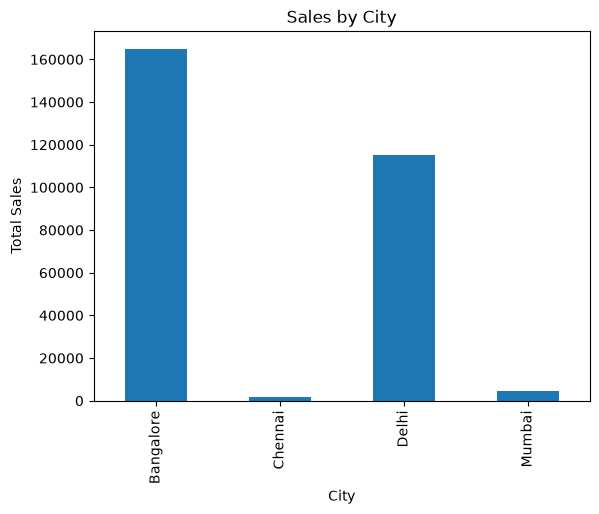

In [45]:
city_sales = df.groupby("City")["Total"].sum()
city_sales.plot(kind="bar")

plt.xlabel("City")
plt.ylabel("Total Sales")
plt.title("Sales by City")

plt.show()